# SOK-1305 — Kapittel 3.1: Enkel lineær regresjon i Python

**Handelshøgskolen ved UiT** · Høst 2026

Denne notebooken følger forelesningsnotatene til forelesningen om enkel lineær regresjon, 25. august 2026.

## Del 0 — Oppsett

In [7]:
%pip install ISLP

  Using cached islp-0.4.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached lifelines-0.30.3-py3-none-any.whl.metadata (3.5 kB)
  Using cached pygam-0.12.0-py3-none-any.whl.metadata (9.8 kB)
  Using cached pytorch_lightning-2.6.5-py3-none-any.whl.metadata (21 kB)
  Using cached torchmetrics-1.9.0-py3-none-any.whl.metadata (23 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
  Using cached autograd-1.9.1-py3-none-any.whl.metadata (6.1 kB)
  Using cached autograd-gamma-0.5.0.tar.gz (4.0 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached formulaic-1.2.2-py3-none-any.whl.metadata (7.0 kB)
  Using cached pytz-2026.3.post1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cache

In [8]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
from scipy.stats import t as tdist

import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import ModelSpec as MS, summarize

np.set_printoptions(suppress=True)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# Boston datasett
Dette er et datasett fra ISLP boka, dokumentasjon finner du [her](https://islp.readthedocs.io/en/latest/datasets/Boston.html)!

In [39]:
Boston = load_data('Boston')
Boston

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.0063,18.0000,2.3100,0,0.5380,6.5750,65.2000,4.0900,1,296,15.3000,4.9800,24.0000
1,0.0273,0.0000,7.0700,0,0.4690,6.4210,78.9000,4.9671,2,242,17.8000,9.1400,21.6000
2,0.0273,0.0000,7.0700,0,0.4690,7.1850,61.1000,4.9671,2,242,17.8000,4.0300,34.7000
3,0.0324,0.0000,2.1800,0,0.4580,6.9980,45.8000,6.0622,3,222,18.7000,2.9400,33.4000
4,0.0691,0.0000,2.1800,0,0.4580,7.1470,54.2000,6.0622,3,222,18.7000,5.3300,36.2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.0626,0.0000,11.9300,0,0.5730,6.5930,69.1000,2.4786,1,273,21.0000,9.6700,22.4000
502,0.0453,0.0000,11.9300,0,0.5730,6.1200,76.7000,2.2875,1,273,21.0000,9.0800,20.6000
503,0.0608,0.0000,11.9300,0,0.5730,6.9760,91.0000,2.1675,1,273,21.0000,5.6400,23.9000
504,0.1096,0.0000,11.9300,0,0.5730,6.7940,89.3000,2.3889,1,273,21.0000,6.4800,22.0000


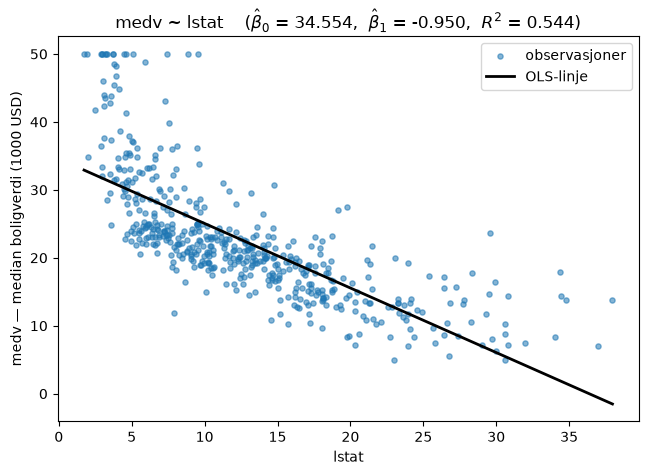

In [65]:
def plott_mot_medv(feature, data=Boston, ax=None):
    """Spredningsplott av medv mot valgt prediktor, med OLS-linja lagt oppå."""
    x, y = data[feature], data["medv"]

    if ax is None:
        ax = subplots(figsize=(7.5, 5))[1]
    ax.scatter(x, y, s=14, alpha=.55, color="tab:blue", label="observasjoner")

    res = sm.OLS(y, MS([feature]).fit_transform(data)).fit()
    b0, b1 = res.params.iloc[0], res.params.iloc[1]

    g = np.linspace(x.min(), x.max(), 100)
    ax.plot(g, b0 + b1 * g, color="black", lw=2, label="OLS-linje")

    ax.set_xlabel(feature)
    ax.set_ylabel("medv — median boligverdi (1000 USD)")
    ax.set_title(f"medv ~ {feature}    "
                 rf"($\hat\beta_0$ = {b0:.3f},  $\hat\beta_1$ = {b1:.3f},  $R^2$ = {res.rsquared:.3f})")
    ax.legend()
    return res


res = plott_mot_medv("lstat")

# OLS linja for to ulike feature's
I koden under velger vi å lage en enkel lineær regresjon, hvor vår $Y$ er feature'n `medv` (median boligverdi i 1000 $), mot `lstat` (lower status of the population (percent), tatt fra bokas [hjemmeside](https://islp.readthedocs.io/en/latest/datasets/Boston.html)). Så ser vi også på $Y$ mot `rm` som vår feature (altså vår $X$, antall soverom per bolig).

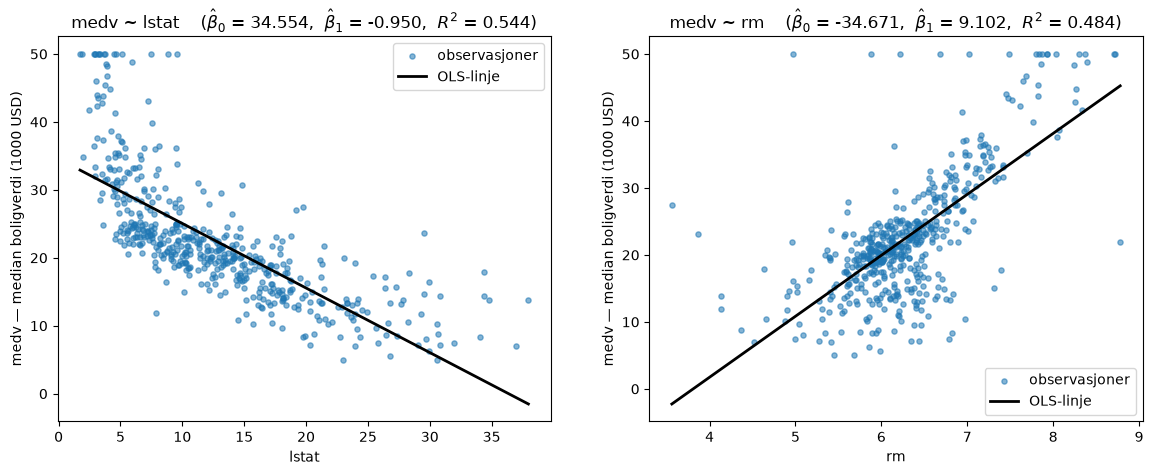

In [66]:
fig, (ax1, ax2) = subplots(1, 2, figsize=(14, 5))
plott_mot_medv("lstat", ax=ax1)
plott_mot_medv("rm", ax=ax2)

______________

## RSS er et areal - Visualisering

På tavla definerte vi residualet for observasjon $i$ som avstanden fra
punktet ned til linja:

$$e_i = y_i - \hat{y}_i, \qquad RSS = \sum_{i=1}^{n} e_i^2$$

Navnet *residual sum of squares* er helt bokstavelig. Kvadrerer vi et
residual, får vi arealet av et kvadrat med sidelengde $|e_i|$. RSS er
den samlede flata av alle disse kvadratene.

Under tegner vi de samme 12 nabolagene to ganger: én gang med
OLS-linja, én gang med en helt annen linje jeg har funnet på. Kvadratene
er tegnet i oransje.

**Før du kjører cella:** hvilken av de to figurene tror du får størst
samlet oransje flate — og hvorfor er det nettopp den flata minste
kvadraters metode gjør så liten som mulig?

*Merk: `set_aspect("equal")` er nødvendig for at kvadratene faktisk skal
se ut som kvadrater. Uten den strekkes de til rektangler, og poenget
forsvinner.*

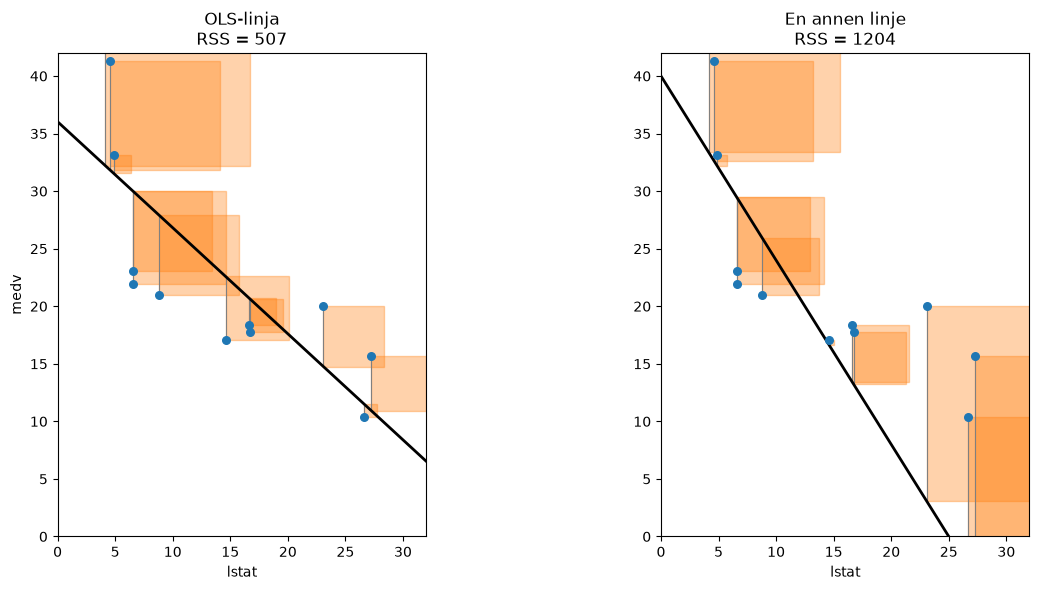

In [48]:
import numpy as np
from matplotlib.pyplot import subplots
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from ISLP import load_data

Boston = load_data("Boston")


def ols(x, y):
    b1 = ((x - x.mean()) * (y - y.mean())).sum() / ((x - x.mean()) ** 2).sum()
    return y.mean() - b1 * x.mean(), b1


# Få punkter, ellers blir det uleselig
d = Boston.sample(12, random_state=3).sort_values("lstat")
xs, ys = d["lstat"].to_numpy(), d["medv"].to_numpy()

fig, akser = subplots(1, 2, figsize=(13, 6))
linjer = [(*ols(xs, ys), "OLS-linja"), (40.0, -1.6, "En annen linje")]

for ax, (b0, b1, tittel) in zip(akser, linjer):
    yh = b0 + b1 * xs
    e = ys - yh
    for xi, yi, yhi, ei in zip(xs, ys, yh, e):
        ax.add_patch(Rectangle((xi, min(yi, yhi)), abs(ei), abs(ei),
                               facecolor="tab:orange", alpha=.35,
                               edgecolor="tab:orange"))
        ax.plot([xi, xi], [yi, yhi], color="grey", lw=.8)
    g = np.linspace(0, 32, 2)
    ax.plot(g, b0 + b1 * g, color="black", lw=2)
    ax.scatter(xs, ys, s=30, color="tab:blue", zorder=5)
    ax.set_aspect("equal")          # ellers er ikke kvadratene kvadrater
    ax.set_xlim(0, 32); ax.set_ylim(0, 42)
    ax.set_xlabel("lstat")
    ax.set_title(f"{tittel}\nRSS = {(e**2).sum():.0f}")
akser[0].set_ylabel("medv")
plt.tight_layout()

R^2 = 1 - 19,472 / 42,716 = 0.5441


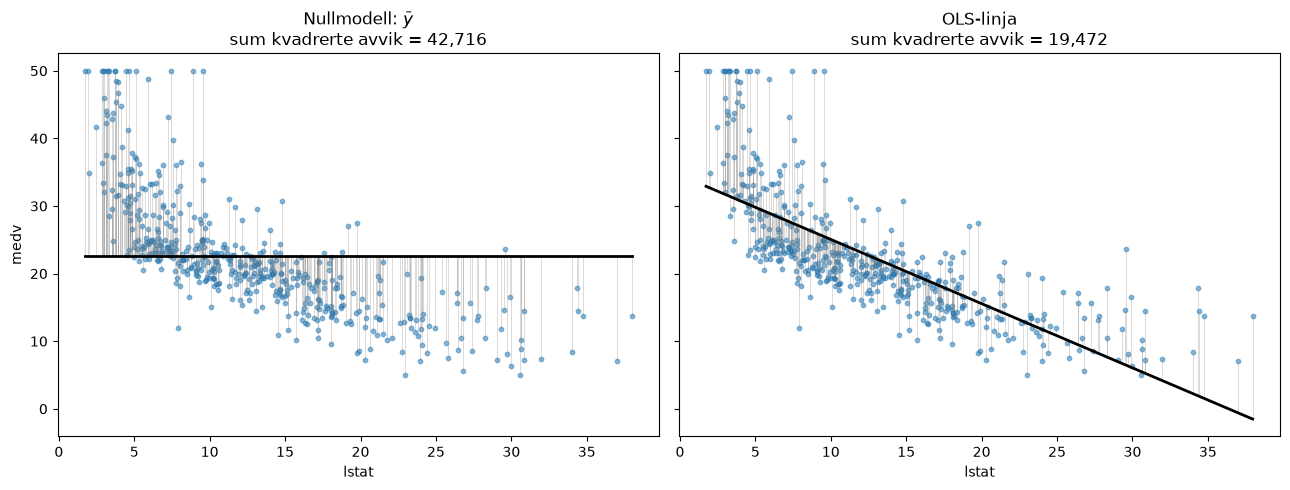

In [49]:
x = Boston["lstat"].to_numpy()
y = Boston["medv"].to_numpy()
b0, b1 = ols(x, y)

TSS = ((y - y.mean()) ** 2).sum()
RSS = ((y - b0 - b1 * x) ** 2).sum()

fig, akser = subplots(1, 2, figsize=(13, 5), sharey=True)
modeller = [(np.full_like(x, y.mean()), r"Nullmodell: $\bar{y}$", TSS),
            (b0 + b1 * x, "OLS-linja", RSS)]

for ax, (pred, tittel, verdi) in zip(akser, modeller):
    for xi, yi, pi in zip(x, y, pred):
        ax.plot([xi, xi], [yi, pi], color="grey", lw=.4, alpha=.5)
    ax.scatter(x, y, s=10, alpha=.5)
    o = np.argsort(x)
    ax.plot(x[o], pred[o], color="black", lw=2)
    ax.set_xlabel("lstat")
    ax.set_title(f"{tittel}\nsum kvadrerte avvik = {verdi:,.0f}")
akser[0].set_ylabel("medv")
plt.tight_layout()

print(f"R^2 = 1 - {RSS:,.0f} / {TSS:,.0f} = {1 - RSS/TSS:.4f}")

Text(0.5, 1.0, 'RSE = 6.22 — 78% innenfor ±1 RSE')

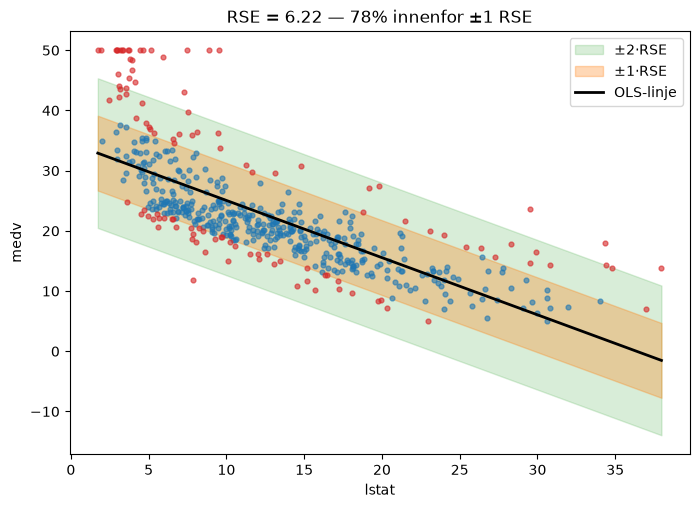

In [50]:
yh = b0 + b1 * x
e = y - yh
n = len(x)
RSE = np.sqrt((e ** 2).sum() / (n - 2))

g = np.linspace(x.min(), x.max(), 100)
linje = b0 + b1 * g

ax = subplots(figsize=(8, 5.5))[1]
ax.fill_between(g, linje - 2*RSE, linje + 2*RSE, alpha=.18,
                color="tab:green", label="±2·RSE")
ax.fill_between(g, linje - RSE, linje + RSE, alpha=.30,
                color="tab:orange", label="±1·RSE")
ax.plot(g, linje, color="black", lw=2, label="OLS-linje")

innenfor = np.abs(e) <= RSE
ax.scatter(x[innenfor], y[innenfor], s=12, color="tab:blue", alpha=.6)
ax.scatter(x[~innenfor], y[~innenfor], s=12, color="tab:red", alpha=.6)
ax.set_xlabel("lstat"); ax.set_ylabel("medv"); ax.legend()
ax.set_title(f"RSE = {RSE:.2f} — {innenfor.mean():.0%} innenfor ±1 RSE")

# Iris: lineær regresjon som klassifikator
`iris` inneholder 150 iriser fordelt likt på tre arter — *setosa*,
*versicolor* og *virginica* — med fire mål på hver blomst. Vi bruker
kronbladlengde (`petal_length`) til å forutsi art.

Datasettet ligger ikke i ISLP, men følger med `scikit-learn` biblioteket.

![Alternativ tekst](https://miro.medium.com/v2/resize:fit:1400/0*GVjzZeYrir0R_6-X.png)


In [58]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.datasets import load_iris

d = load_iris(as_frame=True)
iris = d.frame.rename(columns={
    "sepal length (cm)": "sepal_length", "sepal width (cm)": "sepal_width",
    "petal length (cm)": "petal_length", "petal width (cm)": "petal_width"})
iris["art"] = pd.Categorical.from_codes(d.target, d.target_names)

print(iris["art"].value_counts(), "\n")
iris.groupby("art", observed=True)["petal_length"].agg(["mean", "min", "max"])

art
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64 



,mean,min,max
art,,,
setosa,1.4620,1.0000,1.9000
versicolor,4.2600,3.0000,5.1000
virginica,5.5520,4.5000,6.9000


## Vi koder artene som tall

Artene er ord, ikke tall. For å bruke OLS må vi oversette:

$$Y = \begin{cases}
1 & \text{setosa} \\
2 & \text{versicolor} \\
3 & \text{virginica}
\end{cases}$$

Så tilpasser vi $\hat{y} = \hat\beta_0 + \hat\beta_1 \cdot \texttt{petal\_length}$,
runder prediksjonen til nærmeste hele tall, og oversetter tilbake til
artsnavn.

**Se på tabellen fra forrige celle før du kjører.** Kronbladlengden går fra
1,46 cm hos setosa via 4,26 hos versicolor til 5,55 hos virginica. Artene
ligger altså pent på rekke langs akkurat den variabelen vi bruker.

Hvor bra tror du dette går?

In [59]:
X = sm.add_constant(iris[["petal_length"]])

kode = {"setosa": 1, "versicolor": 2, "virginica": 3}
y = iris["art"].map(kode).astype(float)

res = sm.OLS(y, X).fit()
tilbake = {v: k for k, v in kode.items()}
pred = pd.Series(np.clip(np.round(res.predict(X)), 1, 3)).map(tilbake)

print(f"beta_petal_length = {res.params.iloc[1]:.4f}")
print(f"R^2               = {res.rsquared:.4f}")
print(f"treffsikkerhet    = {(pred.values == iris['art'].values).mean():.2%}")

beta_petal_length = 0.4404
R^2               = 0.9007
treffsikkerhet    = 95.33%


## 95 % riktig. Er vi ferdige?

$R^2 = 0.90$ og 95,3 % av blomstene havner i riktig art. Det ser ut som en
solid modell.

Men her er spørsmålet som avslører alt: **hvorfor skulle setosa være 1 og
virginica være 3?** Det er tre arter. Det finnes ingen naturlig rekkefølge
mellom dem — ingen art er «mindre» enn en annen. Jeg kunne like gjerne
nummerert dem alfabetisk, etter når de ble oppdaget, eller helt tilfeldig.

Det finnes seks måter å nummerere tre arter på. Alle er like forsvarlige.
La oss prøve dem alle.

In [60]:
from itertools import permutations

rader = []
for perm in permutations(d.target_names):
    k = {a: i + 1 for i, a in enumerate(perm)}
    yk = iris["art"].map(k).astype(float)
    r = sm.OLS(yk, X).fit()
    tb = {v: kk for kk, v in k.items()}
    p = pd.Series(np.clip(np.round(r.predict(X)), 1, 3)).map(tb)
    rader.append({"koding": " < ".join(perm),
                  "beta": round(r.params.iloc[1], 4),
                  "R2": round(r.rsquared, 4),
                  "treff": f"{(p.values == iris['art'].values).mean():.1%}"})

print(pd.DataFrame(rader).sort_values("R2", ascending=False).to_string(index=False))
print(f"\nGjettenivå (tre like store klasser): {1/3:.1%}")

                         koding    beta     R2 treff
setosa < versicolor < virginica  0.4404 0.9007 95.3%
virginica < versicolor < setosa -0.4404 0.9007 95.3%
setosa < virginica < versicolor  0.3013 0.4215 48.0%
versicolor < virginica < setosa -0.3013 0.4215 48.0%
versicolor < setosa < virginica  0.1391 0.0899 33.3%
virginica < setosa < versicolor -0.1391 0.0899 33.3%

Gjettenivå (tre like store klasser): 33.3%


## Resultatet

Treffsikkerheten spenner fra **95,3 % ned til 33,3 %** — og 33,3 % er
nøyaktig det du får ved å gjette i blinde med tre like store klasser. Den
verste kodingen gir altså en modell helt uten verdi.

Legg merke til at radene kommer i **par**. Snur du en koding helt om,
skifter $\hat\beta_1$ fortegn, men $R^2$ og treffsikkerheten er identiske.
Det er speilbildet av samme modell. Det er bare tre reelle alternativer,
ikke seks.

Og her er poenget: **de 95 % var flaks.** Ikke flaks med dataene, men flaks
med at nummereringen vår tilfeldigvis stemte overens med hvordan artene
ligger langs kronbladlengden. Hadde jeg nummerert artene alfabetisk —
setosa, versicolor, virginica — ville jeg fått samme heldige treff. Hadde
jeg nummerert dem etter latinsk navnelengde, eller etter hvilken jeg liker
best, ville modellen kollapset.

Dette er nøyaktig innvendingen ISLP reiser i avsnitt 4.2. Kodingen
1, 2, 3 smugler inn to påstander:

1. **En rekkefølge** — versicolor plasseres mellom de to andre.
2. **Lik avstand** — spranget setosa→versicolor er like stort som
   versicolor→virginica.

For iris er begge grunnløse. Arter er ikke rangert.

Figuren under viser den beste og den verste kodingen side om side. De
stiplede linjene er avrundingsgrensene ved 1,5 og 2,5.

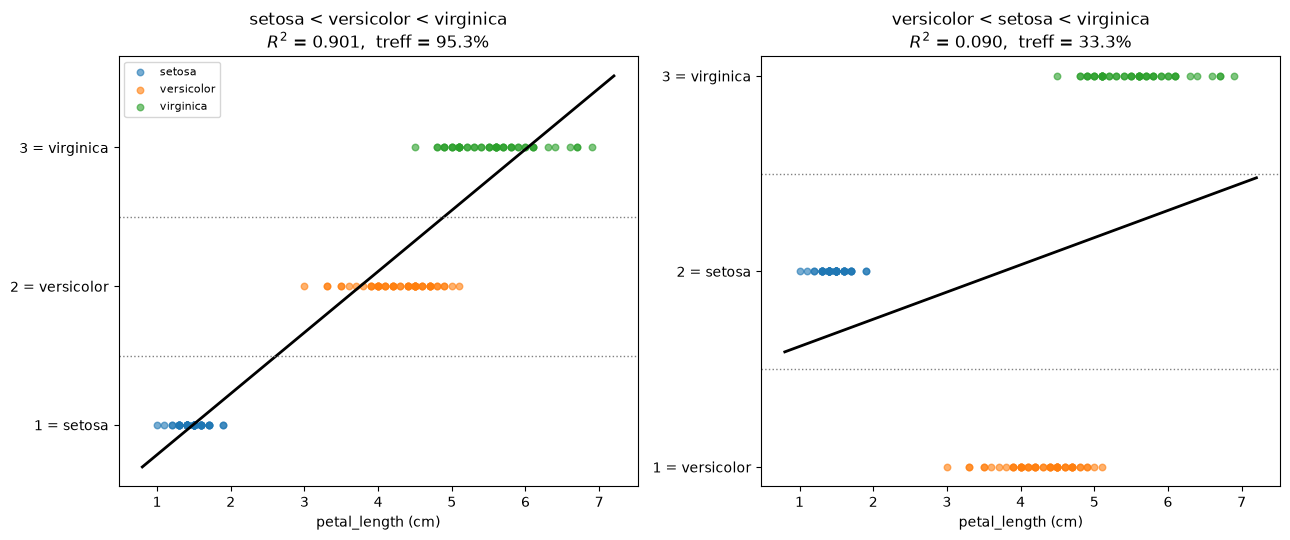

In [61]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots

farger = {"setosa": "tab:blue", "versicolor": "tab:orange",
          "virginica": "tab:green"}
valgte = [("setosa", "versicolor", "virginica"),
          ("versicolor", "setosa", "virginica")]

fig, akser = subplots(1, 2, figsize=(13, 5.5), sharex=True)
for ax, perm in zip(akser, valgte):
    k = {a: i + 1 for i, a in enumerate(perm)}
    yk = iris["art"].map(k).astype(float)
    r = sm.OLS(yk, X).fit()
    tb = {v: kk for kk, v in k.items()}
    p = pd.Series(np.clip(np.round(r.predict(X)), 1, 3)).map(tb)

    for a in farger:
        m = iris["art"] == a
        ax.scatter(iris.loc[m, "petal_length"], yk[m], s=22, alpha=.6,
                   color=farger[a], label=a)
    g = np.linspace(0.8, 7.2, 50)
    ax.plot(g, r.params.iloc[0] + r.params.iloc[1] * g, color="black", lw=2)
    for terskel in (1.5, 2.5):
        ax.axhline(terskel, color="grey", ls=":", lw=1)
    ax.set_yticks([1, 2, 3])
    ax.set_yticklabels([f"{i+1} = {a}" for i, a in enumerate(perm)])
    ax.set_xlabel("petal_length (cm)")
    ax.set_title(f"{' < '.join(perm)}\n"
                 f"$R^2$ = {r.rsquared:.3f},  "
                 f"treff = {(p.values == iris['art'].values).mean():.1%}")
akser[0].legend(fontsize=8)
plt.tight_layout()

## Sammenligning: multinomisk logistisk regresjon

En ekte klassifikasjonsmetode behandler artene som det de er — tre
navn uten rangering. Da finnes det ingen koding å velge feil.

ISLP påpeker dette eksplisitt for multinomisk logistisk regresjon: valget
av basiskategori påvirker koeffisientene, men de tilpassede verdiene og
prediksjonene forblir de samme uansett.

Kjør cella under og se at treffsikkerheten ikke rører seg, uansett hvordan
vi stokker om på artene.

In [63]:
from sklearn.linear_model import LogisticRegression

for perm in [("setosa", "versicolor", "virginica"),
             ("versicolor", "setosa", "virginica"),
             ("virginica", "setosa", "versicolor")]:
    y_omkodet = iris["art"].cat.reorder_categories(perm)
    m = LogisticRegression(max_iter=1000).fit(iris[["petal_length"]], y_omkodet)
    print(f"{' < '.join(perm):<40} treff = "
          f"{m.score(iris[['petal_length']], y_omkodet):.1%}")

print("\nLineær regresjon:     95.3 % ned til 33.3 %  <- avhenger av kodingen")
print("Multinomisk logistisk: 95.3 % uansett          <- uavhengig av hvordan du koder det")

setosa < versicolor < virginica          treff = 95.3%
versicolor < setosa < virginica          treff = 95.3%
virginica < setosa < versicolor          treff = 95.3%

Lineær regresjon:     95.3 % ned til 33.3 %  <- avhenger av kodingen
Multinomisk logistisk: 95.3 % uansett          <- uavhengig av hvordan du koder det


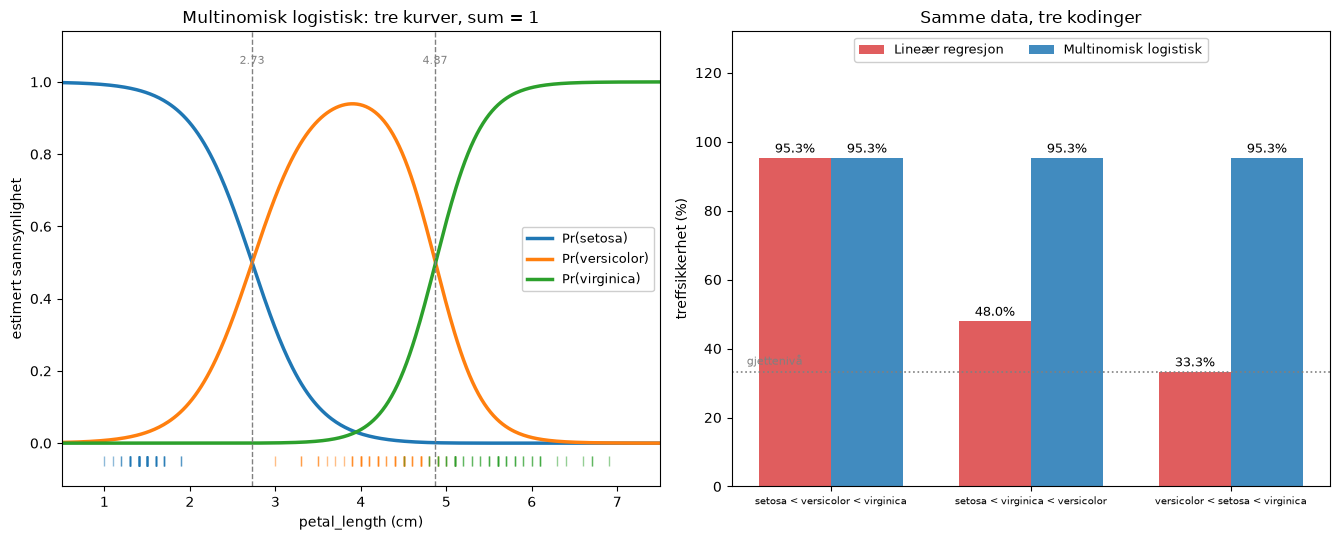

In [64]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from sklearn.linear_model import LogisticRegression

farger = {"setosa": "tab:blue", "versicolor": "tab:orange",
          "virginica": "tab:green"}

# De tre reelt forskjellige kodingene (å snu en koding gir samme modell speilvendt)
kodinger = [("setosa", "versicolor", "virginica"),
            ("setosa", "virginica", "versicolor"),
            ("versicolor", "setosa", "virginica")]

lin_treff, log_treff = [], []
for perm in kodinger:
    k = {a: i + 1 for i, a in enumerate(perm)}
    r = sm.OLS(iris["art"].map(k).astype(float), X).fit()
    tb = {v: kk for kk, v in k.items()}
    p = pd.Series(np.clip(np.round(r.predict(X)), 1, 3)).map(tb)
    lin_treff.append((p.values == iris["art"].values).mean())

    y_omkodet = iris["art"].cat.reorder_categories(perm)
    log_treff.append(LogisticRegression(max_iter=1000)
                     .fit(iris[["petal_length"]], y_omkodet)
                     .score(iris[["petal_length"]], y_omkodet))

fig, (a1, a2) = subplots(1, 2, figsize=(13.5, 5.5))

# ---- Venstre: hva modellen faktisk estimerer ----
m = LogisticRegression(max_iter=1000).fit(iris[["petal_length"]], iris["art"])
g = pd.DataFrame({"petal_length": np.linspace(0.5, 7.5, 400)})   # DataFrame, ikke array
P = m.predict_proba(g)
gv = g["petal_length"].to_numpy()

vinner = np.array(m.classes_)[P.argmax(1)]
grenser = gv[np.where(vinner[:-1] != vinner[1:])[0]]      # der argmax skifter

for i, a in enumerate(m.classes_):
    a1.plot(gv, P[:, i], lw=2.5, color=farger[a], label=f"Pr({a})")
for gr in grenser:
    a1.axvline(gr, color="grey", ls="--", lw=1)
    a1.text(gr, 1.05, f"{gr:.2f}", ha="center", fontsize=8, color="grey")
for a in farger:                                          # teppe av faktiske data
    xs = iris.loc[iris["art"] == a, "petal_length"]
    a1.plot(xs, np.full(len(xs), -0.05), "|", color=farger[a], alpha=.5, ms=7)

a1.set_ylim(-0.12, 1.14)
a1.set_xlim(0.5, 7.5)
a1.set_xlabel("petal_length (cm)")
a1.set_ylabel("estimert sannsynlighet")
a1.set_title("Multinomisk logistisk: tre kurver, sum = 1")
a1.legend(fontsize=9, loc="center right", framealpha=.95)

# ---- Høyre: invariant vs. ikke ----
xp = np.arange(3)
w = 0.36
b1 = a2.bar(xp - w/2, [v*100 for v in lin_treff], w, color="tab:red",
            alpha=.75, label="Lineær regresjon")
b2 = a2.bar(xp + w/2, [v*100 for v in log_treff], w, color="tab:blue",
            alpha=.85, label="Multinomisk logistisk")
for b in list(b1) + list(b2):
    a2.text(b.get_x() + b.get_width()/2, b.get_height() + 1.5,
            f"{b.get_height():.1f}%", ha="center", fontsize=9)

a2.axhline(100/3, color="grey", ls=":", lw=1.2)
a2.text(-0.42, 100/3 + 2, "gjettenivå", fontsize=8, color="grey")
a2.set_xticks(xp)
a2.set_xticklabels([" < ".join(p) for p in kodinger], fontsize=7.5)
a2.set_ylim(0, 132)
a2.set_ylabel("treffsikkerhet (%)")
a2.set_title("Samme data, tre kodinger")
a2.legend(fontsize=9, loc="upper center", ncol=2, framealpha=.95)

plt.tight_layout()